In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool
import torch.nn as nn

# ── Dataset ──────────────────────────────────────────────────────────────
# MUTAG: 188 small molecular graphs, 2-class classification
# PROTEINS: 1113 graphs, 2-class
datasets = {}
for name in ['MUTAG', 'PROTEINS']:
    datasets[name] = TUDataset(root=f'/tmp/{name}', name=name)

# ── GCN Model ─────────────────────────────────────────────────────────────
class GCN(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = nn.Linear(hidden, out_channels)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

# ── GIN Model ─────────────────────────────────────────────────────────────
class GIN(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        mlp1 = nn.Sequential(nn.Linear(in_channels, hidden), nn.ReLU(),
                              nn.Linear(hidden, hidden))
        mlp2 = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(),
                              nn.Linear(hidden, hidden))
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin   = nn.Linear(hidden, out_channels)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_add_pool(x, batch)   # SUM pool — key difference from GCN
        return self.lin(x)

# ── Training loop ─────────────────────────────────────────────────────────
def train_and_eval(dataset, ModelClass, epochs=100, hidden=64, seed=42):
    torch.manual_seed(seed)
    n = len(dataset)
    train_ds = dataset[:int(0.8*n)]
    test_ds  = dataset[int(0.8*n):]
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=32)

    model = ModelClass(dataset.num_node_features, hidden, dataset.num_classes)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        model.train()
        for data in train_loader:
            opt.zero_grad()
            out  = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)
            loss.backward()
            opt.step()

    model.eval()
    correct = 0
    for data in test_loader:
        pred = model(data.x, data.edge_index, data.batch).argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(test_ds)

# ── Run all combinations ──────────────────────────────────────────────────
import pandas as pd

rows = []
for ds_name, ds in datasets.items():
    for ModelClass in [GCN, GIN]:
        accs = [train_and_eval(ds, ModelClass, seed=s) for s in [0,1,2]]
        mean = sum(accs)/len(accs)
        rows.append({'Dataset': ds_name,
                     'Model':   ModelClass.__name__,
                     'Run1':    round(accs[0],3),
                     'Run2':    round(accs[1],3),
                     'Run3':    round(accs[2],3),
                     'Mean Acc': round(mean,3)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

Processing...
Done!
Processing...
Done!


 Dataset Model  Run1  Run2  Run3  Mean Acc
   MUTAG   GCN 0.684 0.684 0.684     0.684
   MUTAG   GIN 0.842 0.605 0.763     0.737
PROTEINS   GCN 0.247 0.296 0.179     0.241
PROTEINS   GIN 0.368 0.247 0.287     0.300


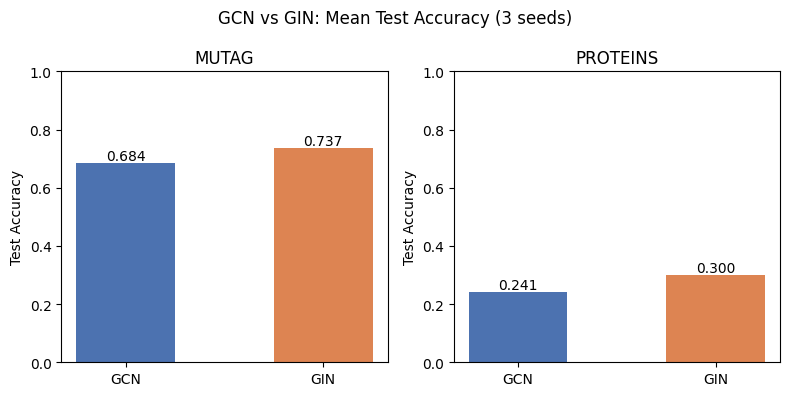

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
models = ['GCN', 'GIN']

for i, ds_name in enumerate(['MUTAG', 'PROTEINS']):
    subset = df[df['Dataset'] == ds_name]
    accs   = subset['Mean Acc'].values
    bars   = axes[i].bar(models, accs, color=['#4C72B0','#DD8452'], width=0.5)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(ds_name)
    axes[i].set_ylabel('Test Accuracy')
    for bar, acc in zip(bars, accs):
        axes[i].text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                     f'{acc:.3f}', ha='center', fontsize=10)

plt.suptitle('GCN vs GIN: Mean Test Accuracy (3 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()